# Practical SBI-17 - Energy-based scoring and flexible refinement of docking runs

Until now we have performed the docking of proteins using three different methods:
FTDock, ZDOCK and PathDock. In this practical, we are going to explore two
downstream manipulations that can be done on the results of docking programs.

- Firstly, we are going to explore the use of an alternative scoring function to re-rank the scoring poses provided by a docking method. From the previous practical you used the native scoring function of each method, but there are other scoring
functions available that can be used. To that end, we will use the energy-scoring
function of __pyDock__.

- Secondly, as protein are dynamic entities, and so the interaction of proteins, we will apply limited flexibility to refine the docking poses. By applying flexibility, we will refine the dockings (basically by optimizing the side-chain positions), and re-rank the posed base on the refined structures. The __FireDock__ program will be used for the flexible refinement.

## 1. Energy-based scoring of TolB-Pal complex with PyDock

The TolB and Pal protein complex in E. coli is involved int maintaining the stability of the outer membrane. This complex is important because is the target of the colicins antibiotics (protein antibiotics) using this complex to expedite the entrance in the bacteria. Nuclease colicins competitively recruit TolB using their natively disordered regions (NDRs) to disrupt its complex with Pal, which is thought to trigger translocation of the toxin across a locally destabilized.

We will use pyDock 3.0 to perform a complete docking execution, including rigid-body docking and energy-based scoring. We will generate rigid-body docking poses with ZDOCK for this target, which will be scored with energy-based pyDock scoring function. Then, you will have to make your choice and select what you consider to be the best model from our starting pool of docking poses. Finally, RMSD comparison with the real 3-D complex structure will be done to check the results of our results. We could in principle run ZDOCK separately as we did in the
previous practical and then import the results into pyDock.
All pyDock jobs are launched as follow:

`pyDock3 dockname module`

The argument dockname (similar to project name) is arbitrarily chosen by the user. In our example, we will use T26 as dockname. The different modules that can be used in pyDock are listed here:

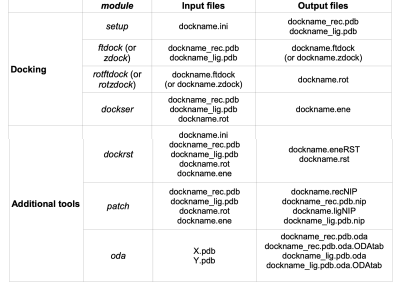

### 1.2 Prepare the input files
Firstly, download the coordinates of the unbound proteins from the protein databank (rcsb.org) and extract the relevant chains for the reference complex (2HQS); no need for the unbound complexes:

1C5K, chain A – Unbound TolB
1OAP, chain A – Unbound Pal
2HQS, chains A, H – Xray TolB-Pal reference complex.

`` awk '$1=="ATOM" && substr($0,22,1)=="A"' 2HQS.pdb > 2hqs_A_H.pdb``
`` awk '$1=="ATOM" && substr($0,22,1)=="H"' 2HQS.pdb >> 2hqs_A_H.pdb ``

Give the following names:
- 1c5k.pdb (TolB, receptor protein)
- 1oap.pdb (Pal, ligand protein)
- 2hqs_A_H.pdb (reference complex)

In addition, you need an ".ini" file, which contains the information about the chains to dock from each PDB file, in order to create a new pair of parsed PDB files suitable for pyDock. Thus, you have to create a text file called `T26.ini` using your favorite text editor and include the following information:

The “mol” chain name is the original chain ID in the input pdb files whereas the “newmol” will be the new chain ID in the parsed pdb files suitable for pyDock. The “newmol” chain names must be different for the receptor and the ligand (so that you can distinguish the chains when docked!). The pdb in the “.ini” file must correspond to the exact names of the pdb files you have.
Once you have a complete T26.ini file, run the pyDock setup using this command in a single line:

`pyDock3 T26 setup`

This command will create the new PDB files for receptor and ligand `T26_rec.pdb` and
`T26_lig.pdb` respectively. These files will be suitable for pyDock.
In case of PDB with incomplete side-chains, these will be automatically rebuilt with SCWRL 3.0 (http://dunbrack.fccc.edu/), which will be automatically launched within pyDock setup, in the pyDock class installation.


### 1.3 Perform the docking using ZDOCK
ZDOCK job can be submitted within pyDock but we will execute ZDOCK as we learned in the previous session:

`/mnt/NFS_UPF/soft/zdock/IntelP3_Linux/zdock -R T26_rec.pdb -L T26_lig.pdb -o T26.zdock`

The docking will run from 10-15 minutes depending on the load of the computer. You can monitor the progress of the job using the command ‘top -c’; look for the zdock process. 

### 1.4. Transform ZDOCK output to pyDock rot file
Upon finishing the docking, you should have the following file in your directory: T26.zdock.
Now, we need to transform the output data from ZDOCK (T26.zdock) to the rotation and
translation matrix that complies with pyDock format. This file will include the rotation and translation information to transform the original coordinates of receptor and ligand in the docked conformation. This is done by using the following command:

`pyDock3 T26 rotzdock`

This calculation is quite fast, and it will create a T26.rot file containing the transformation matrices for all docking poses. Because of time limitations, in this practical we will only proceed with a subset of docking solutions. For that, you need to edit the T26.rot file to keep just 200 conformations.

__IMPORTANT: Before editing the T26.rot file create a copy to save the entire set of
docking solutions. For instance issuing this command:__

`cp T26.rot T26.rot.backup` 

The way you select the 200 docking solutions is up to you. You could for instance extract 200 randomly selected lines from the file using a scripts or the first 200 or the last 200 lines. A little of command line magic could do the trick. To select the top200 or bottom 200 simply do this:

```
head -200 T26.rot.backup > T26.rot

tail -200 T26.rot.backup > T26.rot
```
### 1.5. Scoring using the pyDock energy function
Next stage is to use pyDock energy function to score and rank all positions by running dockser module with the following command:

`pyDock3 T26 dockser`

__WARNING: Be sure you created a T26.rot file with just 200 conformations, otherwise this step would last several hours.__
This step will take a few minutes. You can track the progress of the program on the terminal where you executed the command above.

When dockser finishes, take a look to output file called `T26.ene` that will look like the following example (with different values depending on the 200 docking solution selected):

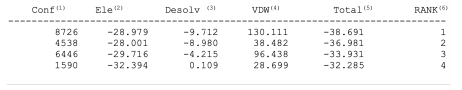

(1) Conf: conformation number of the docking pose (same as that in the rot file, last
column)
(2) Ele: Electrostatic energy component
(3) Delsov: Desolvation energy component
(4) VDW: Van der Waals energy component (term weighted to 0.1 by default)
(5) Total: Total binding energy (Ele + Desolv + 0.1*VDW)
(6) RANK: conformation rank according to its computed binding energy
The ‘Total’ binding energy is the composite scoring function taking into account the contribution of electrostatic, desolvation and VdW components. Note the RANK, indicating the position among all the docking poses according to the pyDock energy function and not to the ZDOCK, even though the docking was done using ZDOCK

### 1.6. Comparison with the real 3D complex structure